In [1]:
import os
import georaster
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.lines import Line2D
import numpy as np
import h5py

from whale_gunshot_localization.utils.transformations import to_spect
from whale_gunshot_localization import config

ccb_data_root = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2], "data_env_conn", "ctd_data")
ccb_data_root_acoustics = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2],"single_examples")

### Experimental Site Figure

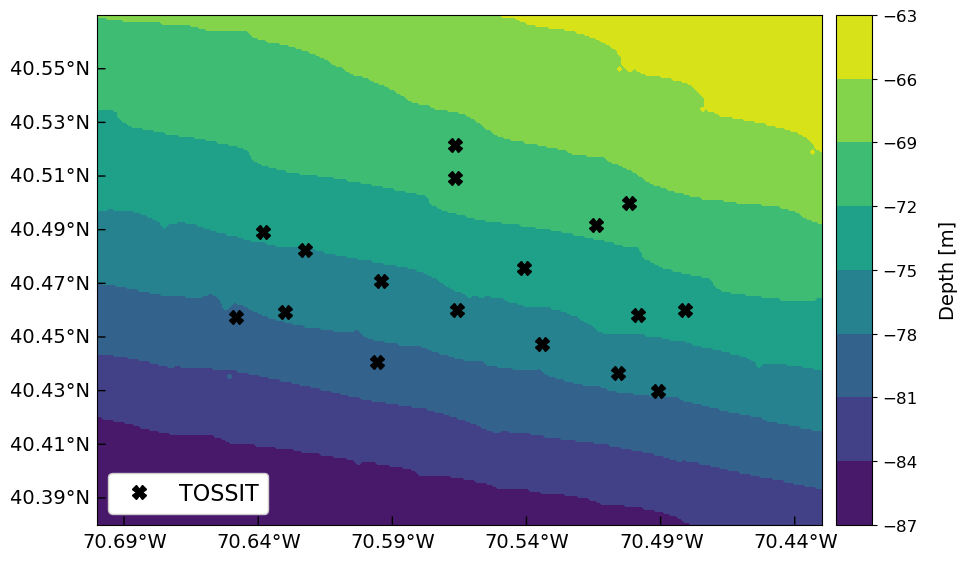

In [36]:
# buffer [in degrees]
b = 0.05

# get TOSSIT position
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
miny = np.around(TOSSIT_latlons[:,0].min(), 2)
maxy = np.around(TOSSIT_latlons[:,0].max(), 2)
minx = np.around(TOSSIT_latlons[:,1].min(), 2)
maxx = np.around(TOSSIT_latlons[:,1].max(), 2)

fig = plt.figure(figsize=(10,10))
m = Basemap(projection='cyl',
            llcrnrlon=minx-b,
            llcrnrlat=miny-b,
            urcrnrlon=maxx+b,
            urcrnrlat=maxy+b,
            resolution='i')
m.drawcoastlines(color="gray")
m.fillcontinents(color='beige')
m.drawparallels(np.arange(miny-b+0.01, maxy+b+0.01, 0.02), labels=[1, 0, 0, 0], fontsize=14, color="k", dashes=[6,1000])
m.drawmeridians(np.arange(minx-b+0.01, maxx+b+0.01, 0.05), labels=[0, 0, 0, 1], fontsize=14, color="k", dashes=[6,1000])

# load the geotiff image, assign it a variable
image = georaster.SingleBandRaster(os.path.join(config['dataset']['data_directory'], 'mikesbathym.tif'),
                                   load_data=(minx-b, maxx+b, miny-b, maxy+b),
                                   latlon=True)

# plot bathymetry
# plt.imshow(-1*image.r, extent=(minx-b, maxx+b, miny-b, maxy+b), zorder=1)
x = np.linspace(m.llcrnrx, m.urcrnrx, image.r.shape[1])
y = np.linspace(m.llcrnry, m.urcrnry, image.r.shape[0])
xx, yy = np.meshgrid(x, y)
m.contourf(xx, yy, np.flip(-1*image.r, axis=0), levels=8)

# plot sensors
m.plot(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0], 'kX', markersize=10, label="TOSSIT")

# plot colorbar and legend
cbar = m.colorbar(location='right')
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Depth [m]", fontsize=14, labelpad=16)
plt.legend(framealpha=1.0, loc='lower left', prop={'size': 16})

plt.show()

### CTDs

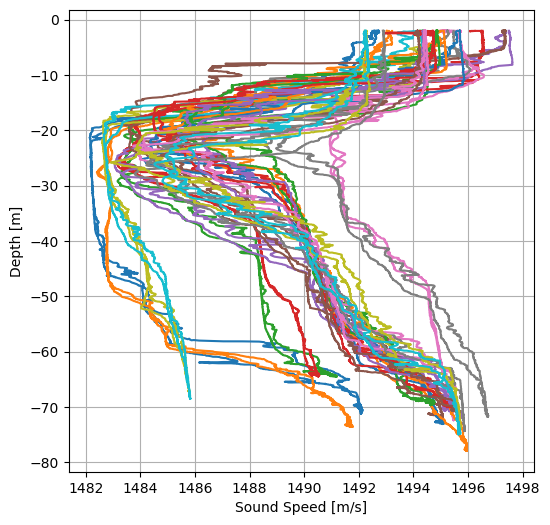

In [3]:
CTD = [11, 33]
D_min = 2
D_max = 80

fig = plt.figure(figsize=(6,6))
CTD_dict = dict()
for c, i in enumerate(range(CTD[0], CTD[1]+1)):
    
    # get date
    with open(os.path.join("/", ccb_data_root, f"CTD{i}.hdr"), "r") as f:
        for _ in range(8):
            next(f)
        line = f.readlines()[0].split(' = ')[-1].rstrip("\n")
        day = int(line[4:6])
    
    # grab data
    with open(os.path.join("/", ccb_data_root, f"CTD{i}.asc"), "r") as f:
        next(f)
        lines = f.readlines()
        for cc, line in enumerate(lines):
            if cc == 0:
                A = np.asarray([[x.rstrip("\n") for x in line.split(' ') if len(x)]], dtype=float)
            else:
                A = np.concatenate((A, np.asarray([[x.rstrip("\n") for x in line.split(' ') if len(x)]], dtype=float)), axis=0)

    if A[:,0].max() > D_max:
        continue
    A = A[np.where((A[:,0] > D_min))[0],:]
    
    # add to plot
    plt.plot(A[:,-1], -A[:,0])
    
# labels
plt.xlabel("Sound Speed [m/s]")
plt.ylabel("Depth [m]")
plt.grid()

plt.show()

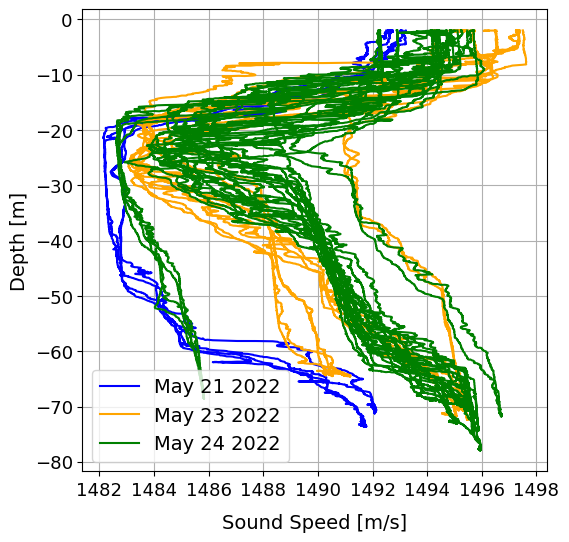

In [44]:
CTD = [11, 33]
D_min = 2
D_max = 80
colors = {21: "blue", 
          22: "black",
          23: "orange",
          24: "green"}
seen = dict([(i, False) for i in range(21,25)])

fig = plt.figure(figsize=(6,6))
CTD_dict = dict()
for c, i in enumerate(range(CTD[0], CTD[1]+1)):
    
    # get date
    with open(os.path.join("/", ccb_data_root, f"CTD{i}.hdr"), "r") as f:
        for _ in range(8):
            next(f)
        line = f.readlines()[0].split(' = ')[-1].rstrip("\n")
        day = int(line[4:6])
        date = line[:11]
    
    # grab data
    with open(os.path.join("/", ccb_data_root, f"CTD{i}.asc"), "r") as f:
        next(f)
        lines = f.readlines()
        for cc, line in enumerate(lines):
            if cc == 0:
                A = np.asarray([[x.rstrip("\n") for x in line.split(' ') if len(x)]], dtype=float)
            else:
                A = np.concatenate((A, np.asarray([[x.rstrip("\n") for x in line.split(' ') if len(x)]], dtype=float)), axis=0)

    if A[:,0].max() > D_max:
        continue
    A = A[np.where((A[:,0] > D_min))[0],:]
    
    # add to plot
    plt.plot(A[:,-1], -A[:,0], color=colors[day], label=date if not seen[day] else None)
    seen[day] = True
    
# labels
plt.xlabel("Sound Speed [m/s]", fontsize=14, labelpad=10)
plt.ylabel("Depth [m]", fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid()
plt.legend(prop={'size': 14})
plt.savefig("ctd.png")

plt.show()

### Data Examples

In [5]:
idx_list = [[49, 53]]

inputs_short = []
sensors_short = []
true_latlon_short = []
associations_short = []
inputs_long = []
sensors_long = []
true_latlon_long = []
for idx in idx_list:
    # load
    with h5py.File(os.path.join("/",ccb_data_root_acoustics,"gunshots" + "".join([f"_{i}" for i in idx]) + ".h5"), "r") as f:
        inputs_short.append(f["/data"][:])
        sensors_short.append(f["/sensors"][:].squeeze())
        true_latlon_short.append(f["/location"][:].T)
        associations_short.append(f["/associations"][:].squeeze())

    try:
        with h5py.File(os.path.join("/",ccb_data_root_acoustics,"gunshots_long" + "".join([f"_{i}" for i in idx]) + ".h5"), "r") as f:
            inputs_long.append(f["/data"][:])
            sensors_long.append(f["/sensors"][:].squeeze())
            true_latlon_long.append(f["/location"][:].T)
        assert (np.array_equal(true_latlon_short[-1], true_latlon_long[-1])), "True locations are different"
    except:
        raise FileNotFoundError("Corresponding long file is not available")
        
# with h5py.File(config['dataset']['data_directory'] + "/VDS_main.h5", 'r', libver='latest') as f:
#     data = f['data'][np.sort(np.random.randint(50000, size=(100,)))]

In [65]:
spect1lt = (np.roll(inputs_long[0][2][:12000],6000) + inputs_long[0][2][12000:]) - (np.roll(inputs_long[0][2][:12000],6000) + inputs_long[0][2][12000:]).mean()
spect1l = to_spect(spect1lt).squeeze()

spect2lt = (np.roll(inputs_long[0][3][:12000],7000) + np.roll(inputs_long[0][3][12000:],3000)) - (np.roll(inputs_long[0][3][:12000],7000) + inputs_long[0][3][12000:]).mean()
spect2l = to_spect(spect2lt).squeeze()

spect17lt = (np.roll(inputs_long[0][16][:12000],4500) + np.roll(inputs_long[0][16][12000:],-900)) - (np.roll(inputs_long[0][16][:12000],4500) + np.roll(inputs_long[0][16][12000:],-900)).mean()
spect17l = to_spect(spect17lt).squeeze()

(-0.5, 2000.5, 231.5, -0.5)

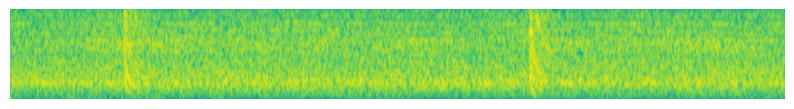

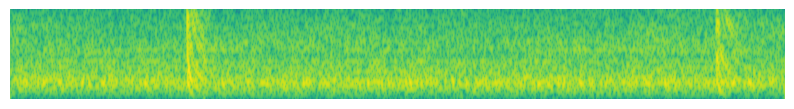

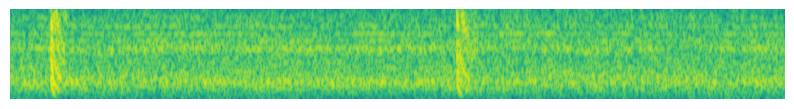

In [45]:
plt.figure(figsize=(10,5))
plt.imshow(spect1l)
plt.axis('off')

plt.figure(figsize=(10,5))
plt.imshow(spect2l)
plt.axis('off')

plt.figure(figsize=(10,5))
plt.imshow(spect17l)
plt.axis('off')

In [42]:
spect1s = to_spect(inputs_short[0][2] - inputs_short[0][2].mean()).squeeze()
spect2s = to_spect(inputs_short[0][3] - inputs_short[0][3].mean()).squeeze()
spect17s = to_spect(inputs_short[0][16] - inputs_short[0][16].mean()).squeeze()
spect18s = to_spect(inputs_short[0][19] - inputs_short[0][19].mean()).squeeze()
spect19s = to_spect(inputs_short[0][20] - inputs_short[0][20].mean()).squeeze()
spect34s = to_spect(inputs_short[0][33] - inputs_short[0][33].mean()).squeeze()

(-0.5, 450.5, 231.5, -0.5)

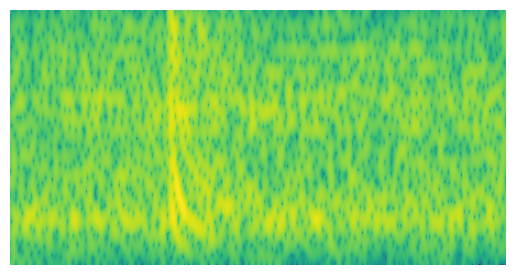

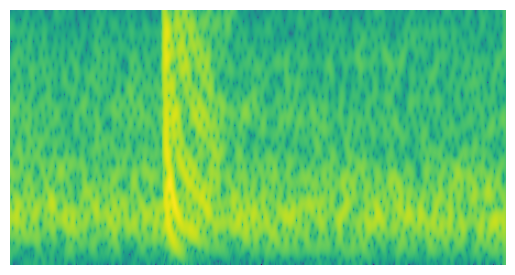

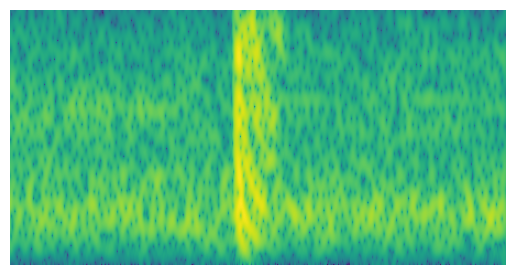

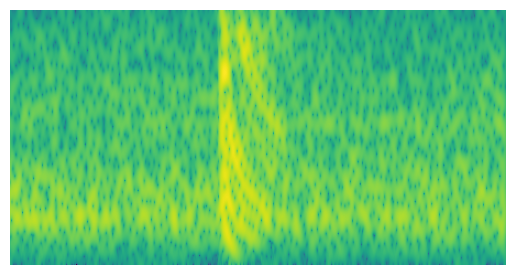

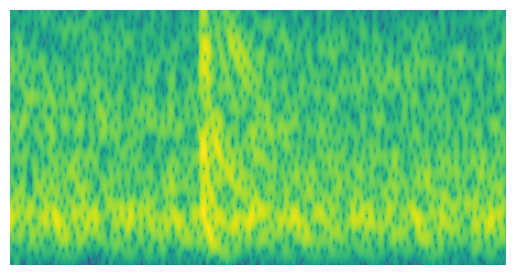

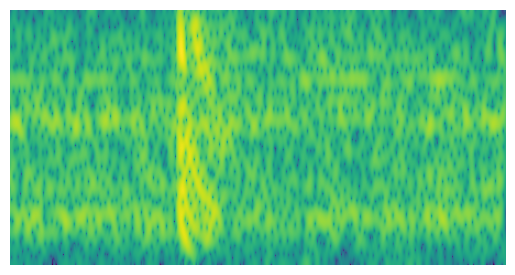

In [43]:
t = 150

plt.figure()
plt.imshow(spect1s[:,t:])
plt.axis('off')

plt.figure()
plt.imshow(spect2s[:,t:])
plt.axis('off')

plt.figure()
plt.imshow(spect17s[:,t:])
plt.axis('off')

plt.figure()
plt.imshow(spect18s[:,t:])
plt.axis('off')

plt.figure()
plt.imshow(spect19s[:,t:])
plt.axis('off')

plt.figure()
plt.imshow(spect34s[:,t:])
plt.axis('off')

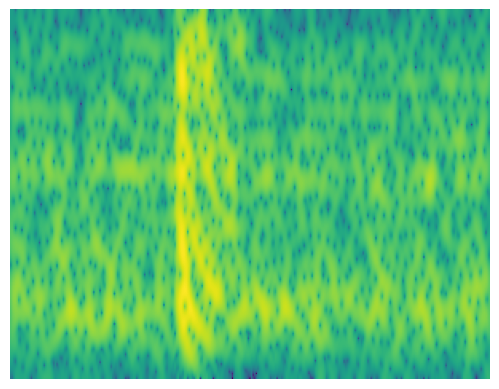

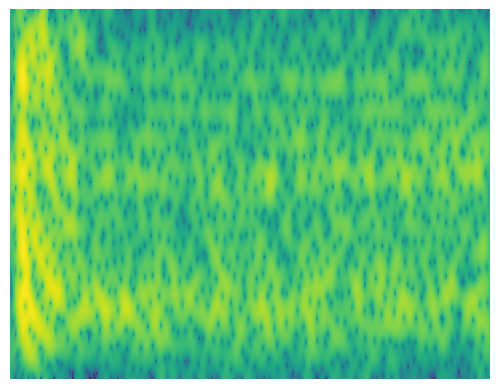

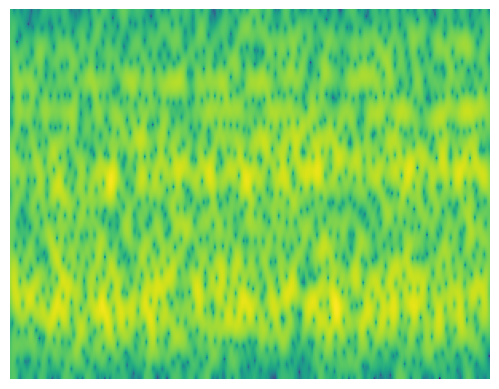

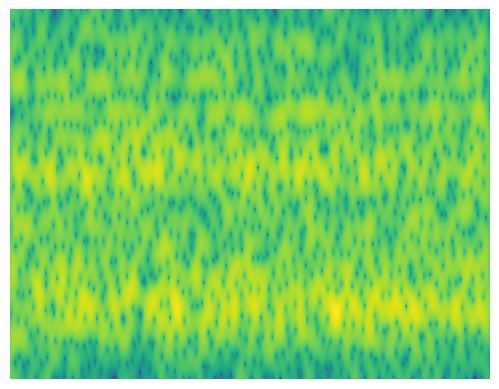

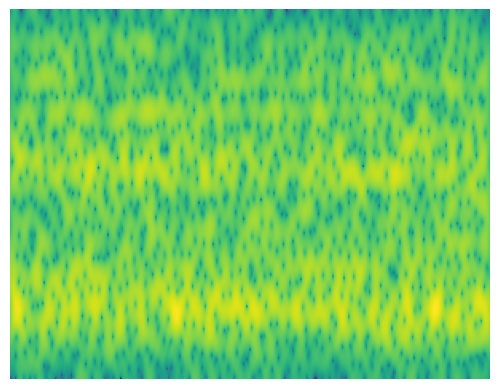

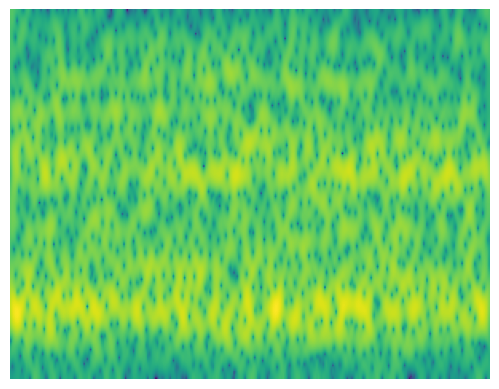

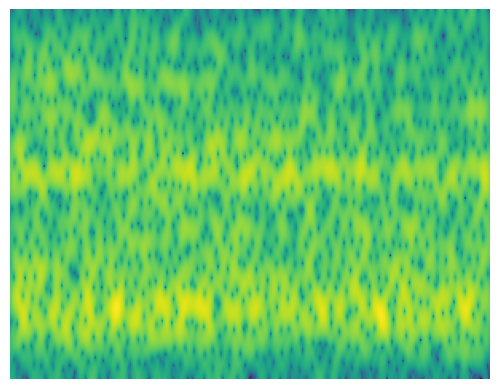

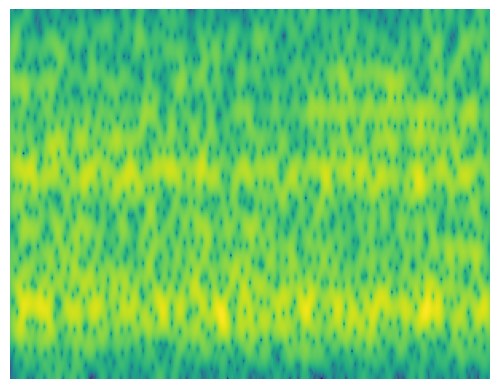

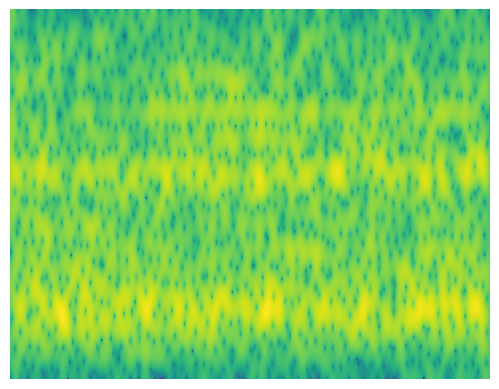

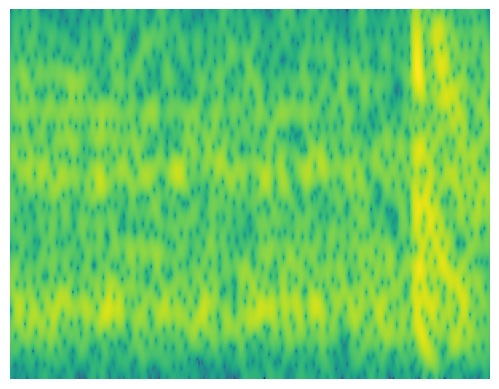

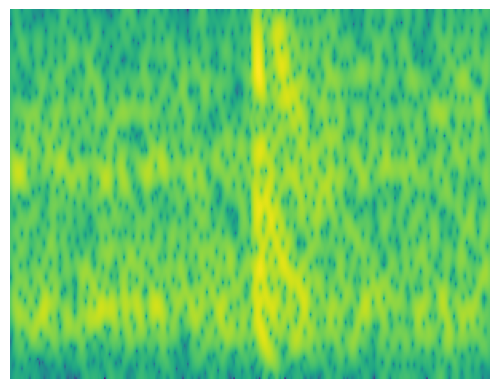

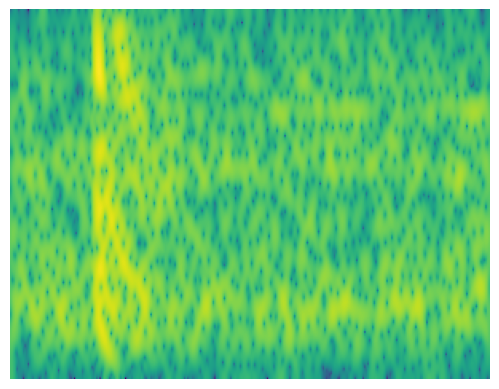

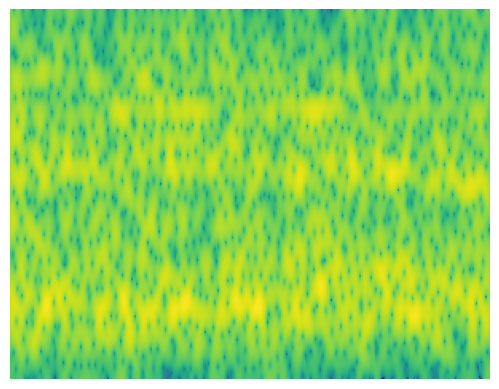

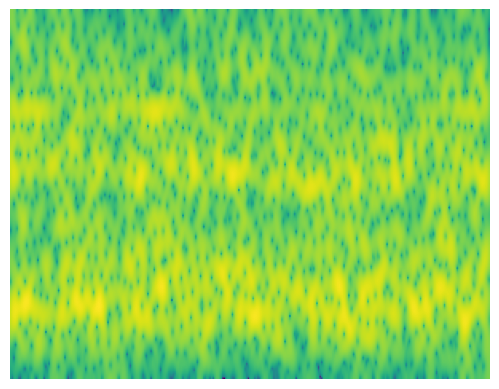

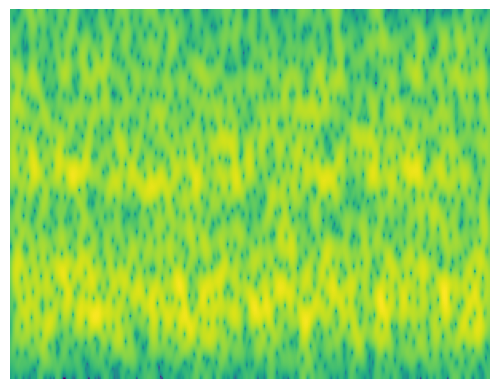

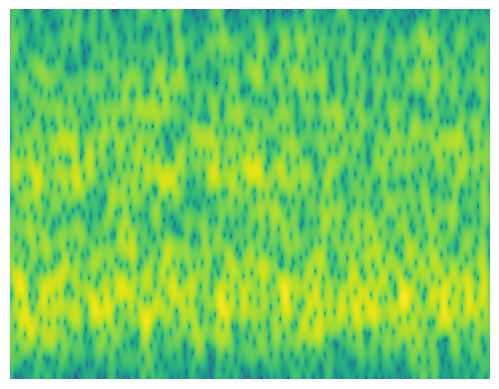

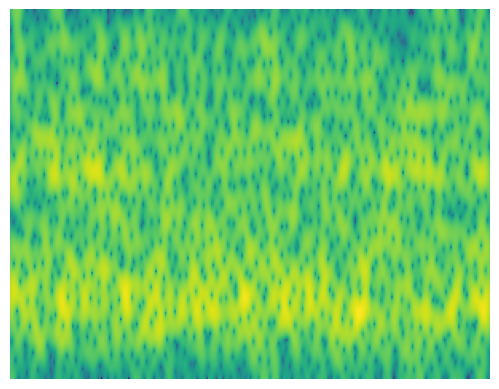

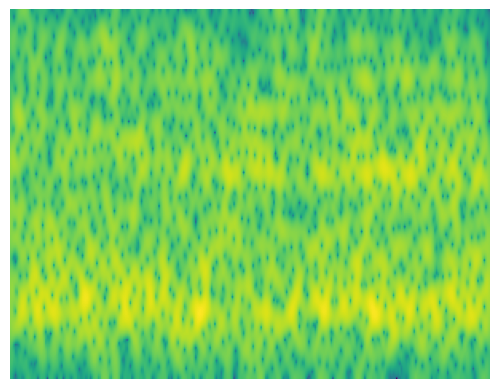

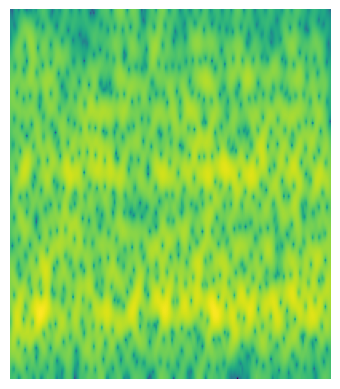

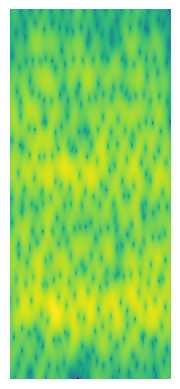

In [69]:
lidx = 2
fs = 600
T = 3
delta = 1
n = 20

start = 0
for e in range(n):
    s = to_spect(spect17lt[start:start+(fs*T)]).squeeze()
    plt.figure()
    plt.imshow(s)
    plt.axis('off')
    start += int(fs*delta)